# Predicción de popularidad de canciones en Spotify

**Autor:** Gino Andrades,Verónica Cereceda

**Fecha de Creación:** Septiembre de 2026

**Versión:** 1.0

## Descripción

Desarrollo de un análisis exploratorio de datos (EDA) y diagnóstico de calidad sobre el dataset de canciones de Spotify, aplicando las etapas iniciales de la metodología CRISP-DM, con el fin de identificar los patrones, calidad y variables relevantes que describen la popularidad musical.

## Información general

Realizar un análisis exploratorio de los datos, incluyendo preparación, transformación y diagnóstico de calidad, aplicando la metodología CRISP-DM, con el fin de identificar patrones, calidad de los datos y variables relevantes asociadas al nivel de popularidad de las canciones.

## **1. Configuración del Entorno**

Se prepara el entorno de trabajo,se descarga el dataset desde el repositorio de GitHub del proyecto, se importan las librerías necesarias para el análisis y se carga el archivo CSV en un Data para su exploración.

### *1.1 Descarga del Dataset*

In [1]:
!wget https://raw.githubusercontent.com/VeritoCR/Repositorio_Spotify_Tracks/refs/heads/main/data/Spotify_Tracks_Dataset.csv

--2026-09-05 12:15:12--  https://raw.githubusercontent.com/VeritoCR/Repositorio_Spotify_Tracks/refs/heads/main/data/Spotify_Tracks_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20118244 (19M) [text/plain]
Saving to: ‘Spotify_Tracks_Dataset.csv.27’

Spotify_Tracks_Data 100%[===================>]  19.19M  34.9MB/s    in 0.6s    

2026-09-05 12:15:16 (34.9 MB/s) - ‘Spotify_Tracks_Dataset.csv.27’ saved [20118244/20118244]



### *1.2 Importaciones necesarias para trabajar.*

In [2]:
!pip install wordcloud==1.9.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.7/550.7 kB 4.7 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import set_config
from wordcloud import WordCloud

### *1.3 Cargar los registros a la variable "data" con pandas*

Se carga el dataset **Spotify_Tracks_Dataset.csv** directamente desde el repositorio de GitHub del proyecto, y se realiza una primera inspección general para conocer su tamaño, tipos de datos y estructura antes de iniciar el diagnóstico de calidad.

In [4]:
data=pd.read_csv('Spotify_Tracks_Dataset.csv')

### *1.4 Definicion de la Variable Objetivo*


In [5]:
target = 'popularity' 

## **2. Exploración Inicial y Perfilamiento**

Se realiza un análisis exploratorio completo del dataset, revisando su estructura, calidad de datos, distribución de variables y las relaciones entre variables,con foco en identificar qué factores se asocian con la variable objetivo. Esta etapa permite detectar problemas de calidad que deberán tratarse en la preparación de datos, así como hallazgos relevantes sobre el comportamiento del catálogo musical.

### *2.1 Inspección Estructural del Dataset*


In [6]:
# Dimensiones del dataset
print(f"Filas: {data.shape[0]}, Columnas: {data.shape[1]}")

Filas: 114000, Columnas: 21


In [7]:
# Tipos de datos por columna
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

El dataset contiene 114.000 registros y 21 columnas. Se observan tres tipos de datos principales:
- **Variables categóricas**:track_id,artists,album_name, track_name,track_genre.
- **Variables numéricas**:popularity,duration_ms,danceability,energy, loudness, tempo,entre otras.
- **Variable booleana**:explicit.

Además, se identifica la columna **Unnamed:0**,que corresponde a un índice residual sin valor analítico.

Atributos Metadatos e Identificación

    Unnamed: 0 (Índice persistido): Índice numérico proveniente de la exportación del archivo CSV. No aporta valor analítico.

    track_id (ID de la Canción): Identificador alfanumérico único otorgado por la API de Spotify para cada pista.

    artists (Artistas): Nombre del artista o los artistas que interpretan la canción (separados por ; si hay colaboraciones).

    album_name (Nombre del Álbum): Álbum en el cual está incluida la canción.

    track_name (Nombre de la Canción): Título de la pista musical.

    track_genre (Género de la Pista): Categoría o género musical asignado a la canción.

Métricas Comerciales y de Contenido

    popularity (Popularidad): Variable objetivo (de 0 a 100). Es un valor calculado por el algoritmo de Spotify basado en el número total de reproducciones recientes de la pista.

    duration_ms (Duración en Milisegundos): Longitud total de la canción expresada en milisegundos (para pasar a segundos, se divide por 1,000).

    explicit (Contenido Explícito): Valor booleano (True/False). Indica si la canción contiene letras explícitas o lenguaje no apto para todo público.

Atributos Musicales y Perceptuales (Audio Features de la API de Spotify)

    danceability (Aptitud para Bailar): Va de 0.0 a 1.0. Describe qué tan adecuada es una pista para bailar basándose en el ritmo, la estabilidad del tempo y la fuerza del pulso.

    energy (Energía): Va de 0.0 a 1.0. Mide la intensidad y actividad percibidas. Pistas ruidosas, rápidas y potentes tienen alta energía (ej. Heavy Metal); pistas tranquilas tienen valores bajos (ej. Bach).

    key (Tonalidad): Tonalidad musical principal estimada de la pista (usando la notación Pitch Class estándar: 0 = Do, 1 = Do#, 2 = Re, etc. Si no se detecta tonalidad, es -1).

    loudness (Sonoridad / Volumen): Volumen promedio global de la pista expresado en decibelios (dB). Los valores suelen oscilar entre -60 dB (muy silencioso) y 0 dB (volumen máximo sin distorsión).

    mode (Modo / Escala): Modalidad de la escala musical (1 = Escala Mayor, 0 = Escala Menor).

    speechiness (Presencia de Palabra Hablada): Va de 0.0 a 1.0. Mide la presencia de palabras habladas en la pista. Valores cercanos a 1.0 corresponden a podcasts o audio-libros; valores sobre 0.66 son tracks de voz hablada; valores entre 0.33 y 0.66 representan música con rap; valores bajo 0.33 son música convencional.

    acousticness (Acusticidad): Va de 0.0 a 1.0. Medida de confianza sobre si la pista fue producida con instrumentos acústicos (sin procesamiento o amplificación eléctrica).

    instrumentalness (Instrumentalidad): Va de 0.0 a 1.0. Predice si una canción no contiene voces. Cuanto más cercano a 1.0, mayor es la probabilidad de que la canción sea puramente instrumental (sin letras ni coros).

    liveness (Presencia de Público / En Vivo): Va de 0.0 a 1.0. Detecta la presencia de público en la grabación. Un valor superior a 0.8 indica una alta probabilidad de que la canción haya sido grabada en vivo (Live concert).

    valence (Positividad Musical / Estado de Ánimo): Va de 0.0 a 1.0. Describe la positividad musical que transmite la pista. Canciones con alta valencia suenan alegres, eufóricas o festivas; canciones con baja valencia suenan tristes, melancólicas o agresivas.

    tempo (Velocidad / BPM): El tempo estimado de la canción en pulsaciones por minuto (BPM - Beats Per Minute).

    time_signature (Compás / Métrica Temporal): Estimación de la métrica del compás (cuántos pulsos entran en cada compás, ej. 4 para compás de 4/4).

### *2.2 Visualización Preliminar de Registros*

In [8]:
# Desplegamos las primeras 5 filas del dataset para una validación visual.
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


El análisis visual de los primeros cinco registros confirma que la estructura relacional del dataset se cargó de acuerdo con los parámetros esperados. Esta vista preliminar resulta clave para auditar el comportamiento inicial de las celdas y analizar la naturaleza de las variables.

### *2.3 Análisis Estadístico Descriptivo*

In [9]:
display(data.drop(columns=['Unnamed: 0']).describe())

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


**Observaciones:**
* Posible valor nulo: duration_ms tiene un mínimo de 0.000 ms. No existen pistas de audio con duración cero, por lo que se trata de registros corruptos que deben filtrarse en la etapa de limpieza.

* Duration_ms: La mediana de duración es de 213 segundos (3,5 minutos),con un promedio de 3,8 minutos. Sin embargo, el máximo llega a 5.237 segundos (87 minutos), lo que indica audiolibros, grabaciones continuas o podcasts.

**Distribuciones y Sesgos Notables**
* popularity:La media es de apenas 33.24 y la mediana 35.0, con un percentil 75 en 50.La gran mayoría de los tracks tiene baja popularidad, concentrándose el éxito masivo (>75-100) en una minoría pequeña del catálogo.

* instrumentalness:El percentil 50 es de solo 0.000042 y el percentil 75 es 0.049.Más del 75% del dataset corresponde a canciones con voz predominante, solo una fracción pequeña supera el umbral comúnmente aceptado (>0.5) para pistas instrumentales puras.

* speechiness:El percentil 75 se sitúa en 0.0845 (8.4%).Menos del 10% del catálogo corresponde a géneros intensivos en texto hablado (como podcasts, audiolibros o rap muy denso).

* liveness:Con una mediana de 0.13 y percentil 75 de 0.27, la inmensa mayoría son canciones de estudio.

### *2.4 Detección de Registros Duplicados*

In [10]:
# Diagnóstico de unicidad sin alterar el DataFrame original
dup_filas_totales = data.drop(columns=['Unnamed: 0']).duplicated().sum()
dup_por_track_id = data.duplicated(subset=['track_id']).sum()
pct_track_id = (dup_por_track_id / len(data)) * 100

dup_por_cancion_artista = data.duplicated(subset=['track_name', 'artists']).sum()
pct_cancion_artista = (dup_por_cancion_artista / len(data)) * 100

print(f"Duplicados en todas las columnas (excluyendo 'Unnamed: 0'): {dup_filas_totales}")
print(f"Duplicados reales por 'track_id': {dup_por_track_id:,} ({pct_track_id:.2f}%)")
print(f"Duplicados por ('track_name', 'artists'): {dup_por_cancion_artista:,} ({pct_cancion_artista:.2f}%)")
print(f"Total de canciones únicas reales (track_id): {data['track_id'].nunique():,}")
print(f"Total de combinaciones únicas (track_name, artists): {data[['track_name','artists']].drop_duplicates().shape[0]:,}")

Duplicados en todas las columnas (excluyendo 'Unnamed: 0'): 450
Duplicados reales por 'track_id': 24,259 (21.28%)
Duplicados por ('track_name', 'artists'): 32,656 (28.65%)
Total de canciones únicas reales (track_id): 89,741
Total de combinaciones únicas (track_name, artists): 81,344


#### *2.4.1 Verificación empírica: ¿son iguales los atributos acústicos entre duplicados de track_id?*

Antes de asumir que estas duplicaciones son inofensivas, revisamos si el mismo track_id trae siempre los mismos valores de audio o si hay algún error de carga escondido ahí. La lógica es simple, si es la misma canción repetida, la desviación estándar de sus atributos acústicos entre repeticiones tiene que dar 0.

In [11]:
atributos_acusticos = ['danceability', 'energy', 'loudness', 'speechiness',
                        'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

repetidos = data[data.duplicated(subset=['track_id'], keep=False)]

std_por_track = repetidos.groupby('track_id')[atributos_acusticos].std()

inconsistentes = std_por_track[(std_por_track.fillna(0) > 0).any(axis=1)]

print(f"Track_ids duplicados analizados: {std_por_track.shape[0]}")
print(f"Track_ids con atributos acústicos INCONSISTENTES entre repeticiones: {inconsistentes.shape[0]}")

Track_ids duplicados analizados: 16641
Track_ids con atributos acústicos INCONSISTENTES entre repeticiones: 0


De los 16.641 track_id que se repiten, ninguno mostró diferencias en sus atributos acústicos entre una fila y otra. Cuando el dataset repite un track_id, repite exactamente los mismos valores de audio, no hay inconsistencia ni error de carga detrás. Esto confirma que la duplicación por track_id es simplemente la misma canción catalogada varias veces.

**¿Por qué se hizo esta verificación?**

Antes de decidir que hacer con las canciones repetidas del dataset, era necesario confirmar algo importante,que esas repeticiones fueran realmente la misma canción con los mismos datos, y no un error de carga que hubiera generado valores distintos bajo el mismo identificador. Si ese fuera el caso, eliminar las copias habría significado perder información real y distinta, no solo redundancia.

Por eso se revisó, para cada canción que aparece más de una vez, si sus características de audio se mantienen exactamente iguales en todas sus repeticiones.

#### *2.4.2 Cardinalidad por género: ¿realmente ~1.000 canciones por género?*

Al revisar la duplicación de track_id notamos un patrón,cada canción repetida aparece bajo un track_genre distinto. Para confirmar si esto responde a una estructura fija del dataset, contamos cuántas canciones tiene cada track_genre.

In [12]:
conteo_generos = data['track_genre'].value_counts()
print(f"Número de géneros distintos: {data['track_genre'].nunique()}")
print(f"Mínimo canciones en un género: {conteo_generos.min()}")
print(f"Máximo canciones en un género: {conteo_generos.max()}")
display(conteo_generos.describe())

# Géneros que se desvían del patrón ~1000
desviados = conteo_generos[(conteo_generos < 950) | (conteo_generos > 1050)]
print(f"\nGéneros que se desvían del patrón esperado (~1000): {len(desviados)}")
display(desviados)

Número de géneros distintos: 114
Mínimo canciones en un género: 1000
Máximo canciones en un género: 1000


count     114.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
Name: count, dtype: float64


Géneros que se desvían del patrón esperado (~1000): 0


Series([], Name: count, dtype: int64)

Los 114 géneros tienen exactamente 1.000 canciones cada uno, sin ninguna excepción. La cuota es perfectamente fija, lo que indica que el dataset se construyó con un muestreo dirigido por género y no como una extracción libre del catálogo,y esa cuota fija es la razón por la que una misma canción termina repetida bajo distintos géneros.

#### *2.4.3 Duplicados 100% exactos*

Con la certeza de que los duplicados por track_id corresponden a la estructura canción-género del dataset, se revisa si además existen filas que sean copia exacta unas de otras en todas las columnas, incluyendo el mismo género repetido un patrón que no respondería a la estructura del dataset, sino a un error real de carga.

In [13]:
data_sin_idx = data.drop(columns=['Unnamed: 0'])
mask_duplicadas = data_sin_idx.duplicated(keep=False)

print(f"Filas duplicadas al 100%: {data_sin_idx.duplicated().sum()}")
print(f"Total de filas involucradas: {mask_duplicadas.sum()}")
print(f"Canciones únicas afectadas: {data[mask_duplicadas]['track_id'].nunique()}")

data[mask_duplicadas].sort_values('track_id')[['track_id','track_name','artists','track_genre','popularity']].head(6)

Filas duplicadas al 100%: 450
Total de filas involucradas: 894
Canciones únicas afectadas: 444


,track_id,track_name,artists,track_genre,popularity
52766,00JZ83w0Qm09f4PwWj06sM,A Good Year For The Roses,George Jones,honky-tonk,12
52714,00JZ83w0Qm09f4PwWj06sM,A Good Year For The Roses,George Jones,honky-tonk,12
39275,02KmEChUwcjxG3G29kbLFT,Shelter Mountain,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,german,16
39307,02KmEChUwcjxG3G29kbLFT,Shelter Mountain,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,german,16
93376,02MRylJ1WAgxzdqfNfdIsR,"Город пышный, город бедный",Oleg Pogudin,romance,0
93331,02MRylJ1WAgxzdqfNfdIsR,"Город пышный, город бедный",Oleg Pogudin,romance,0


Se detectan 444 canciones duplicadas de forma 100% exacta, incluyendo el mismo género repetido ,a diferencia de los duplicados por track_id con género distinto,estos casos son redundancia pura sin ningún valor adicional, probablemente un error en la construcción del dataset original.

### *2.5 Detección de Valores Atípicos (Outliers)*

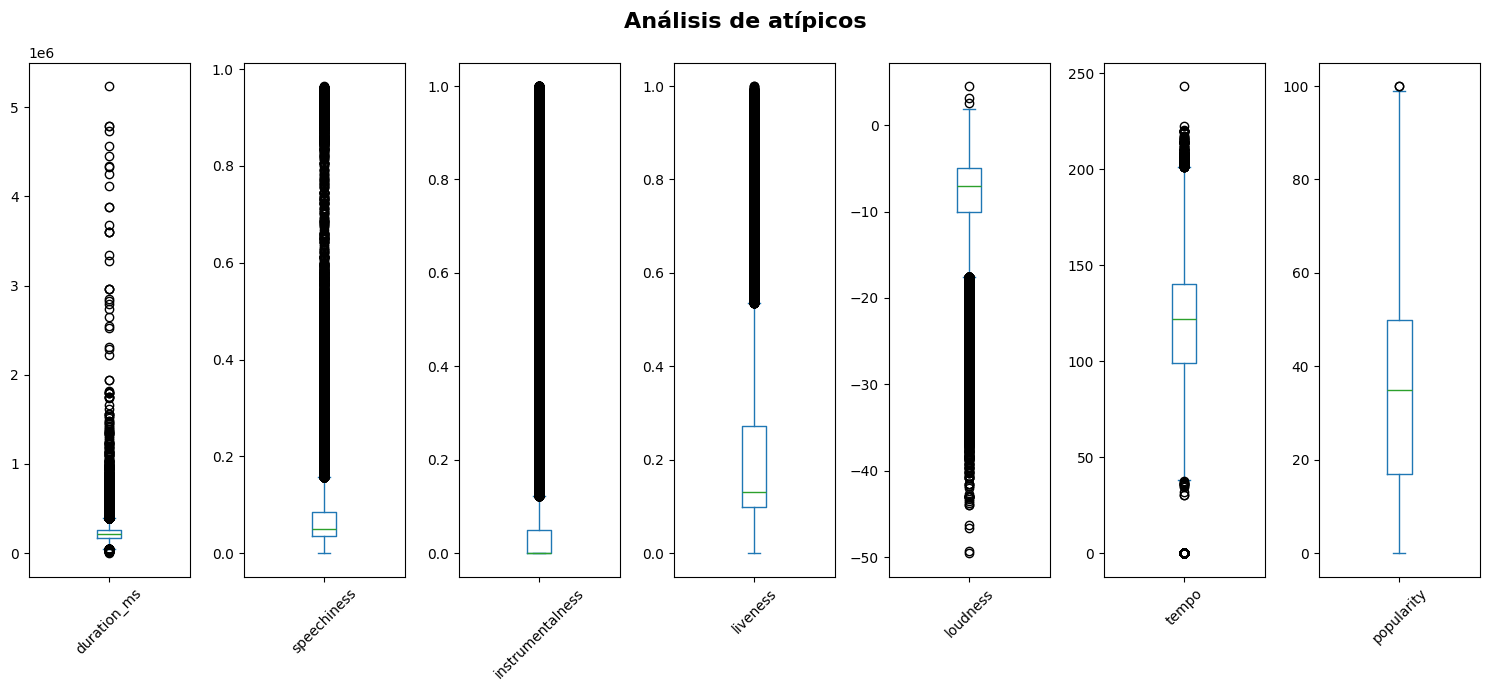

In [14]:
revision_atipicos = ['duration_ms', 'speechiness', 'instrumentalness',	'liveness', 'loudness', 'tempo', 'popularity']
fig, axes = plt.subplots(1, 7 , figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(15,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

**duration_ms (Duración en ms):**
Evidencia una distribución con asimetría positiva severa. Refleja la coexistencia de pistas estándar con audiolibros, podcasts o grabaciones continuas, además de posibles registros con duración 0 ms en la base.

**speechiness, instrumentalness y liveness (Variables con lineas negras de atípicos):** No se trata de fallos de medición, sino del reflejo de que el catálogo comercial típico está compuesto por música cantada de estudio. Las canciones instrumentales puras (>0.2), pistas habladas/rap denso (>0.2) o conciertos en vivo (>0.5) son una minoría natural, pero matemáticamente el criterio IQR los marca masivamente como outliers.

**loudness (Sonoridad en dB):** Pistas extremadamente silenciosas (efectos de sonido, pistas ambientales o silencios al inicio de grabaciones) jalan la cola izquierda. Los atípicos superiores indican posible compresión agresiva de rango dinámico.

**tempo (BPM):Comportamiento:** Los atípicos son puntuales: valores cercanos a 0 BPM (errores de detección de ritmo o silencios) y pistas muy aceleradas ($>200$ BPM, como géneros electrónicos intensos tipo Drum & Bass o Speedcore).

**popularity (Popularidad):** Prácticamente carece de outliers, salvo un par de puntos aislados en el valor máximo (100). Indica que el catálogo cubre todo el espectro de reproducciones de forma continua.

In [15]:
print(f"Registros con duration_ms = 0: {(data['duration_ms']==0).sum()}")
print(f"Popularidad de ese registro: {data[data['duration_ms']==0]['popularity'].values}")

print(f"\nRegistros con duración mayor a 15 minutos: {(data['duration_ms'] > 900000).sum()}")
data.nlargest(10, 'duration_ms')[['track_name', 'artists', 'duration_ms']]

Registros con duration_ms = 0: 1
Popularidad de ese registro: [0]

Registros con duración mayor a 15 minutos: 153


,track_name,artists,duration_ms
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,5237295
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,4730302
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,4563897
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,4447520
13245,Live In Tokyo - Continuous Mix,Mark Farina,4339826
13195,Greenhouse Construction,Mark Farina,4334721
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,4246206
101390,Ocean Waves Sounds,Ocean Sounds,4120258


Solo hay 1 canción con duración 0, y resulta que esa misma tiene popularidad 0.Tiene sentido,si el dato de duración está roto, es lógico que tampoco tenga reproducciones ni popularidad registrada.
Por otro lado, hay 153 canciones que superan los 15 minutos. Pero al mirar los nombres, no son canciones normales,son mezclas continuas de DJ ("Continuous DJ Mix"), sets en vivo o sonidos ambientales como "Ocean Waves Sounds". No es un error de los datos, es que el dataset mezcla distintos tipos de contenido bajo la misma categoría de "canción".

### *2.6 Identificación de Datos Faltantes y Negativos*

#### *2.6.1 Conteo de nulos en variables cuantitativas*

In [16]:
#Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['float64', 'int64']).isnull().sum()

#Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})
#Filtramos las columnas con nulos, ordenamos y desplegamos
resultado = df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False)

if resultado.empty:
    print("No se detectaron valores nulos en ninguna columna numérica del dataset.")
else:
    display(resultado)

No se detectaron valores nulos en ninguna columna numérica del dataset.


#### *2.6.2 Conteo de negativos en variables cuantitativas*

In [17]:
# 1. Calculamos los valores negativos (< 0) en las columnas numéricas
negativos = data.select_dtypes(include=['float64']).lt(0).sum()

# 2. Construimos el DataFrame directamente
df_negativos_cuant = pd.DataFrame({
    'Cantidad_Negativos': negativos,
    'Porcentaje_Negativos': round(negativos / len(data) * 100, 2)
})

# 3. Filtramos las columnas que tengan negativos, ordenamos y desplegamos
display(df_negativos_cuant[df_negativos_cuant['Cantidad_Negativos'] > 0].sort_values(by='Cantidad_Negativos', ascending=False))

,Cantidad_Negativos,Porcentaje_Negativos
loudness,113910,99.92


El 99.92% de los registros presenta valores negativos en la variable loudness. Este comportamiento es coherente con la escala de medida estándar en audio digital (dBFS), donde dB representa la amplitud máxima posible y los valores negativos expresan el nivel de sonoridad promedio de la pista.

### *2.7 Perfilamiento y Consistencia de Atributos Cualitativos*

#### *2.7.1 Análisis Descriptivo de Campos Categorizados*

In [18]:
# Nos muestra todas las variables que son tipo object, nos ayudara a indentificar las variables cualitativas
data.drop(columns=['track_id']).describe(include="object")

,artists,album_name,track_name,track_genre
count,113999,113999,113999,114000
unique,31437,46589,73608,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,279,195,151,1000


#### *2.7.2 Conteo de nulos en variables cualitativas*

In [19]:
# 1. Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['object']).isnull().sum()

# 2. Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})

# 3. Filtramos las columnas con nulos, ordenamos y desplegamos
display(df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False))

,Cantidad_Nulos,Porcentaje_Nulos
artists,1,0.0
album_name,1,0.0
track_name,1,0.0


#### *2.7.3 Exploración de Dominios y Cardinalidad Categórica*

In [20]:
# Seleccionamos automáticamente las columnas de tipo 'object' (categóricas).
variables_cualitativas = data.drop(columns=['track_id', 'track_name', 'artists', 'album_name']).select_dtypes(include=['object']).columns

# Iteramos para inspeccionar la integridad y los valores posibles de cada atributo.
for col in variables_cualitativas:
    print("_" * 110) # Separador
    print(f"\n Valores de {col}: {data[col].unique()}")
print("_" * 110) # Separador

______________________________________________________________________________________________________________

 Valores de track_genre: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-ro

### *2.8 Análisis de Distribución y Sesgo de la Variable Objetivo*

Se analiza la distribución de la variable objetivo popularity, evaluando su forma, tendencia central y grado de asimetría, con el fin de comprender su comportamiento.

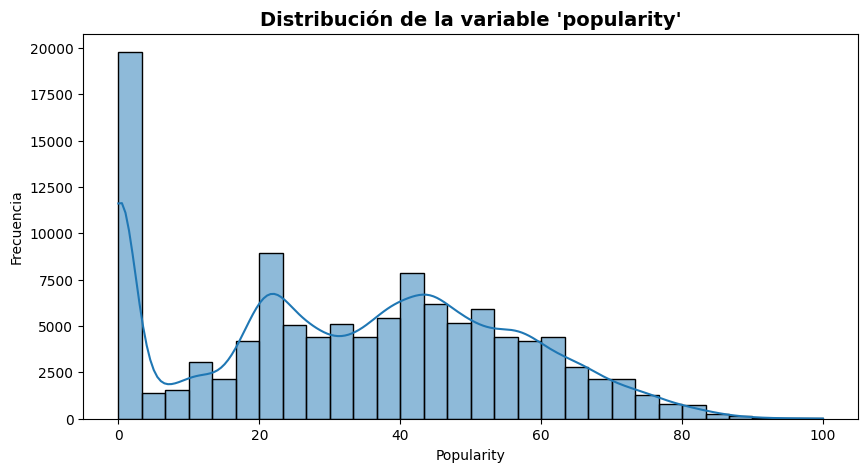

Sesgo de popularity: 0.046
Curtosis: -0.93
Canciones con popularidad 0: 16020, esto equivale a aproximadamente el 14.05% del dataset


In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(data['popularity'], kde=True, bins=30)
plt.title("Distribución de la variable 'popularity'", fontsize=14, fontweight="bold")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()
print(f"Sesgo de popularity: {skew(data['popularity']):.3f}")
print(f"Curtosis: {data['popularity'].kurt():.2f}")
print(f"Canciones con popularidad 0: {(data['popularity'] == 0).sum()}, esto equivale a aproximadamente el {((data['popularity'] == 0).sum()/len(data)) * 100:.2f}% del dataset")

Lo primero que llama la atención es la barra en 0,casi 20.000 canciones tienen popularidad 0, muy por encima de cualquier otro valor. Después de ese pico hay una caída fuerte y recién desde el rango 15-20 en adelante la distribución empieza a tomar una forma más "normal", con la mayor concentración entre 20 y 55, y bajando de a poco hacia los valores altos (80-100).

Ese grupo de canciones con popularidad 0 probablemente corresponde a temas con muy pocas reproducciones o sin suficiente historial para que Spotify les asigne un puntaje mayor.
Lo siguiente es que el skewness dio casi 0 (0.046),lo que normalmente indicaría una distribución simétrica. Pero el gráfico muestra algo distinto, hay un salto grande en 0 que no se ve reflejado en ese número, porque el resto de la distribución compensa el cálculo. Esto muestra que fijarse solo en el valor de skewness puede llevar a una conclusión equivocada si no se revisa también el histograma.

### *2.9 Distribución de las Variables Numéricas*

Se analiza la distribución individual de las principales variables numéricas del dataset, con el fin de identificar su forma, posibles sesgos y rangos de concentración, complementando el análisis de outliers realizado previamente.

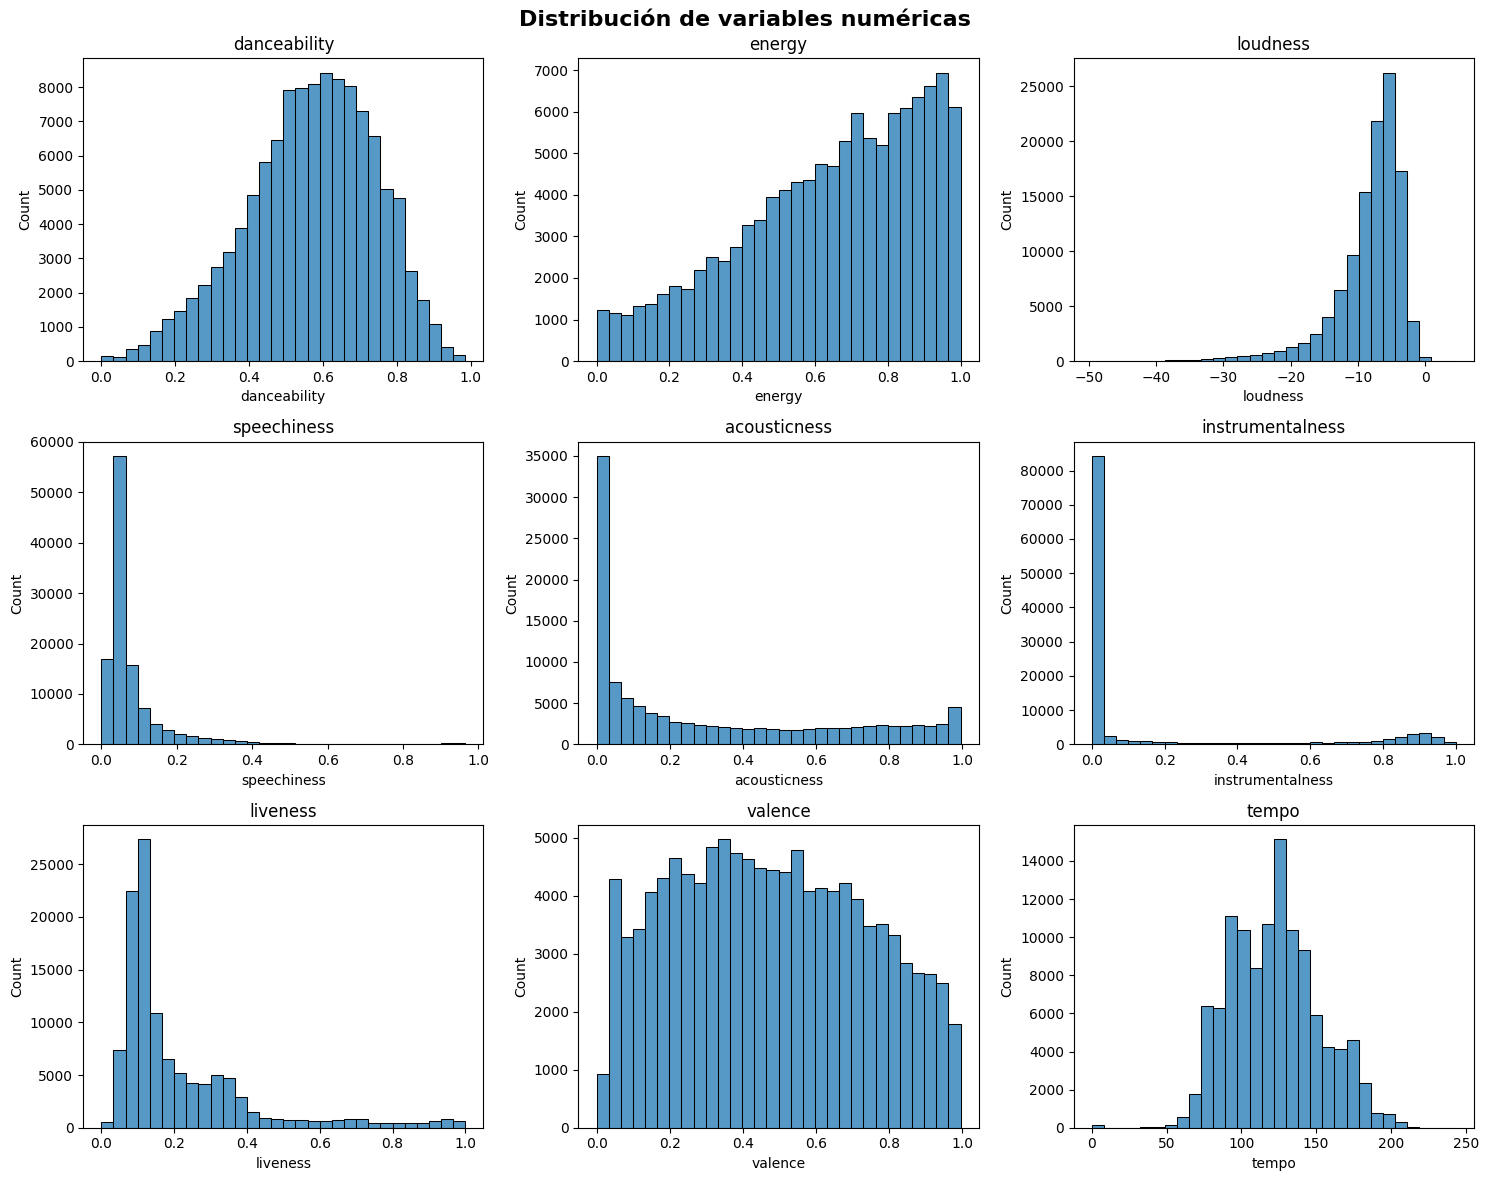

In [22]:
variables_features = ['danceability', 'energy', 'loudness', 'speechiness',
                       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(variables_features):
    sns.histplot(data[col], bins=30, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Distribución de variables numéricas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Varias de las variables de audio muestran distribuciones muy concentradas en valores bajos (speechiness, instrumentalness, liveness, acousticness),lo que significa que estas columnas aportan poca variabilidad para diferenciar canciones entre sí.

**loudness** está concentrada entre -10 y 0 dB, lo que confirma una práctica común de masterización moderna.La cola hacia valores muy negativos probablemente corresponde a grabaciones más antiguas o de menor calidad de producción, lo que podría ser un factor indirecto relacionado con la popularidad.

**danceability**,**valence** y **tempo** son las variables con distribución más "normal" y balanceada del grupo.

El caso de **acousticness** es particular,además de la concentración en 0, tiene un repunte visible cerca de 1.0. Esto sugiere que el data mezcla dos grupos bastante distintos de canciones, más que una transición gradual entre ambos extremos.

En conjunto, el hallazgo más útil de este análisis es que varias variables (speechiness, instrumentalness, liveness) están dominadas por un solo valor y podrían no ser buenos predictores individuales de popularidad, mientras que variables como loudness, danceability y valence, al tener mayor variabilidad, son candidatas más prometedoras para explorar su relación con **popularity**.

### *2.10 Análisis de Correlación y Multicolinealidad*
Se analiza la relación entre las variables numéricas mediante una matriz de correlación, con el fin de identificar qué variables se asocian más con popularity,y detectar posibles relaciones fuertes entre variables.

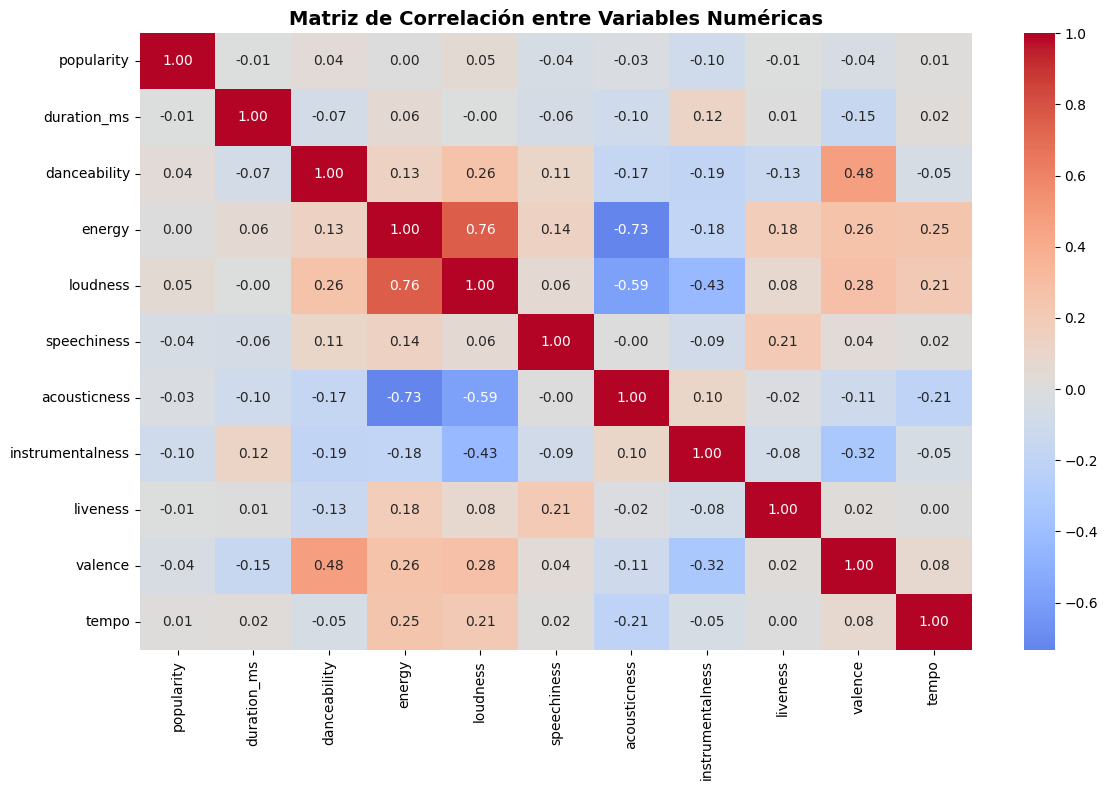

In [23]:
variables_numericas = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                        'valence', 'tempo']

matriz_corr = data[variables_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

El hallazgo más importante de esta matriz es que ninguna variable de audio tiene una correlación lineal relevante con popularity,todos los valores están entre -0.10 y 0.05, prácticamente cero. Esto significa que no existe una única característica de audio. que por sí sola explique por qué una canción es más o menos popular.La variable más cercana es instrumentalness, sugiriendo apenas una leve tendencia de que canciones instrumentales tienden a ser un poco menos populares, pero es una relación muy débil para sacar conclusiones.

Esto es relevante para el proyecto, porque la popularidad probablemente no se explica por atributos de audio de forma aislada, sino por una combinación de varios factores a la vez. Un modelo lineal simple basado en estas variables probablemente tendría un poder predictivo limitado.

### *2.11 Análisis de Correlación de Spearman*

La matriz de correlación de Pearson solo captura relaciones **lineales** entre variables. Para verificar si existen relaciones **no lineales** que no fueron detectadas anteriormente,especialmente con la variable objetivo popularity,se calcula adicionalmente la correlación de Spearman, la cual evalúa la relación entre los rangos de las variables en lugar de sus valores absolutos.

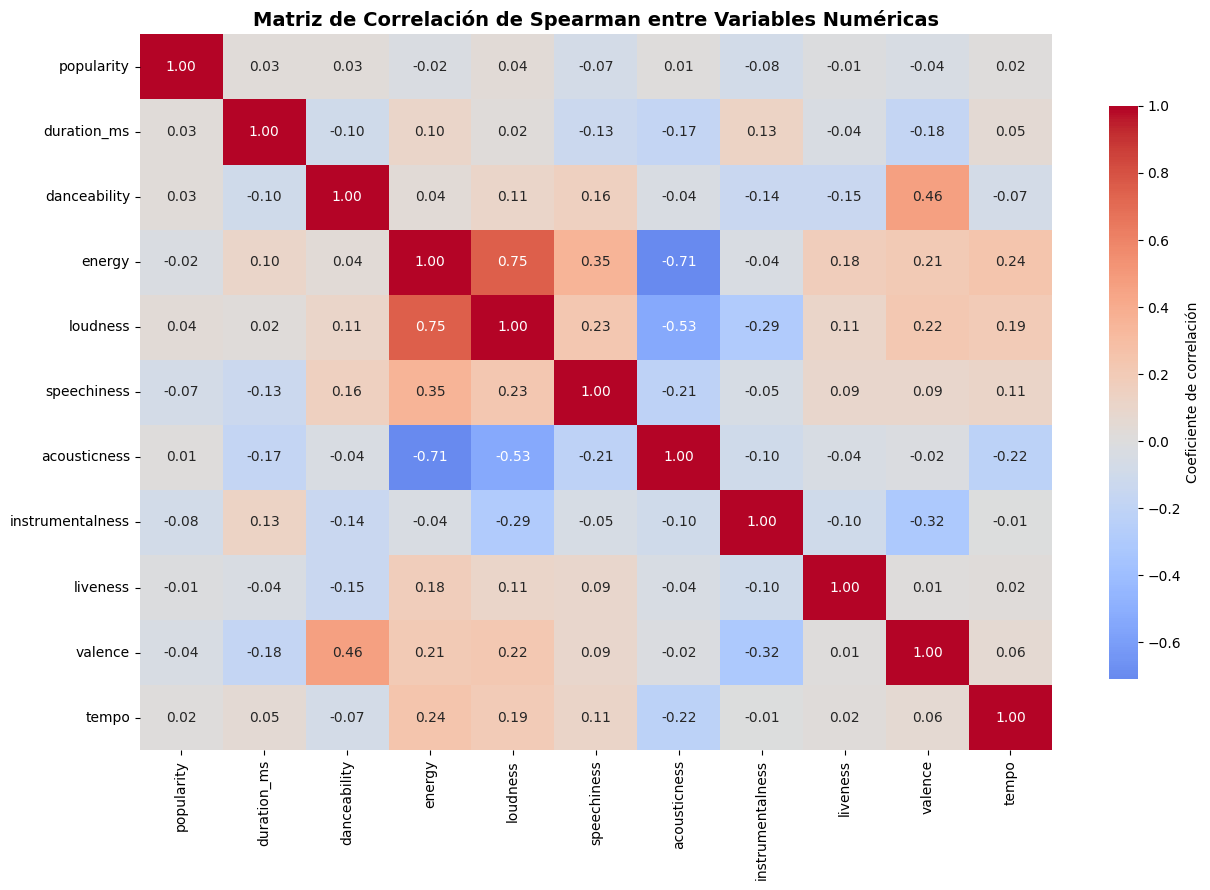

In [24]:
matriz_spearman = data[variables_numericas].corr(method='spearman')

plt.figure(figsize=(13, 9))
sns.heatmap(matriz_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'})
plt.title("Matriz de Correlación de Spearman entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La matriz de Spearman confirma lo observado con Pearson,tampoco existe una relación relevante entre popularity y las variables de audio. Los valores se mantienen igual de bajos entre -0.08 y 0.04, por lo que descartar relaciones lineales no estaba ocultando una relación no lineal más fuerte — simplemente no hay una asociación fuerte de ningún tipo entre estas variables individuales y la popularidad.


### *2.12 Análisis de Correlación de Atributos Numéricos con la Popularidad*

Identificar qué variables numéricas tienen un impacto con el éxito de una canción en Spotify, y detectar qué atributos no muestran una relación lineal directa con la popularidad (valores cercanos a cero). Esto orienta la selección de características (feature selection) para la etapa de modelado predictivo.

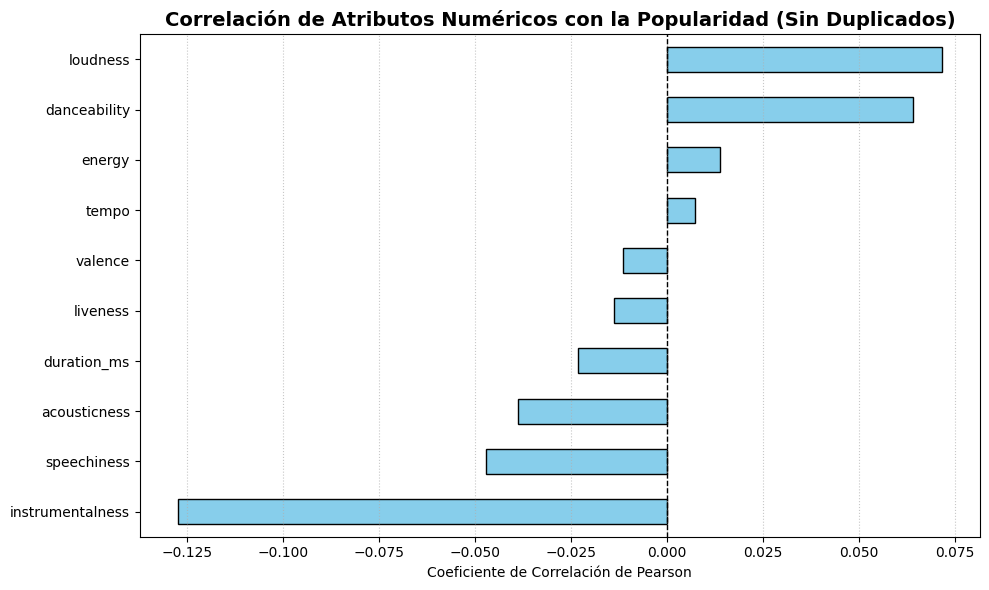

In [25]:
# 1. Asegurar la selección sin alterar listas globales
cols_corr = [col for col in variables_numericas if col != 'popularity'] + ['popularity']

# 2. Matriz sobre el conjunto sin duplicados
corr_series = (
    data.drop_duplicates(subset=['track_id'])[cols_corr]
    .corr(method='pearson')['popularity']
    .drop('popularity')
    .sort_values(ascending=True)
)

# 3. Gráfico
plt.figure(figsize=(10, 6))
corr_series.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Correlación de Atributos Numéricos con la Popularidad (Sin Duplicados)', fontsize=14, fontweight="bold")
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### *2.13 Relación entre popularity y Variables Categóricas*

Dado que las matrices de correlación de Pearson y Spearman no evidenciaron relaciones relevantes entre popularity y las variables de audio, se explora la relación de la variable objetivo con variables categóricas del dataset,el género musical **track_genre** y el carácter explícito de la canción **explicit**, con el fin de identificar si estos factores están más asociados al nivel de popularidad.

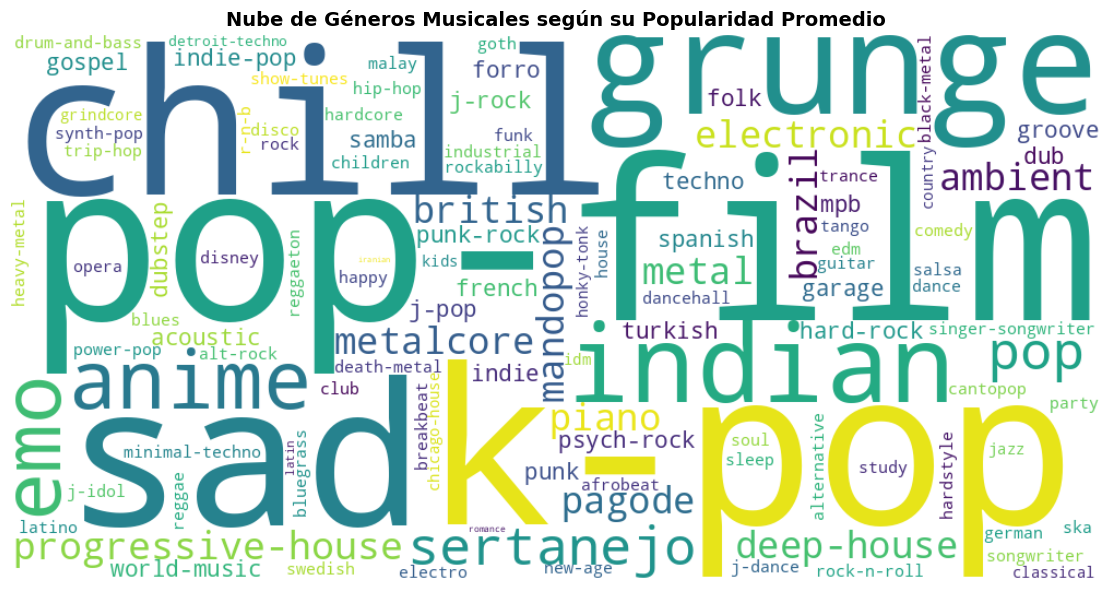

In [26]:
# 1. Calculamos la popularidad promedio por género 
popularidad_genero = data.groupby('track_genre')['popularity'].mean()

# 2. Convertimos la serie de Pandas a un diccionario {género: popularidad_promedio}
frecuencias_genero = popularidad_genero.to_dict()

# 3. Generamos la nube de palabras asignando el tamaño según la popularidad
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    colormap='viridis' # Esquema de colores 
).generate_from_frequencies(frecuencias_genero)

# 4. Graficamos la nube
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Ocultamos los ejes X e Y
plt.title("Nube de Géneros Musicales según su Popularidad Promedio", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When 

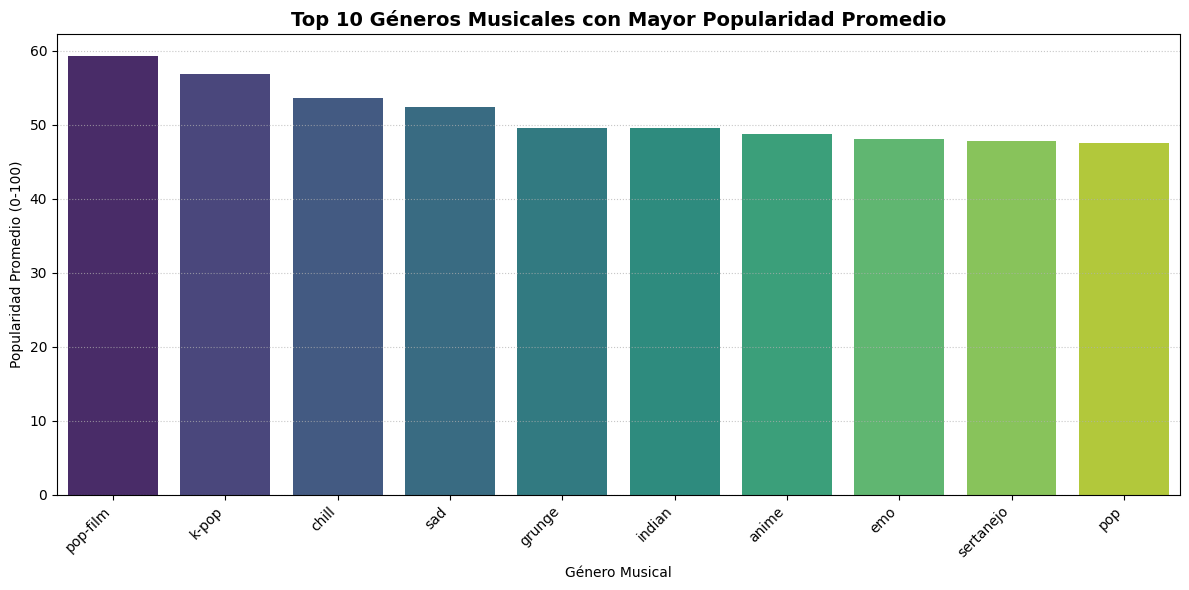

In [27]:
# 1. Agrupar por género, calcular la popularidad promedio y ordenar de mayor a menor
top10_generos = data.groupby('track_genre')['popularity'].mean().reset_index()
top10_generos = top10_generos.sort_values('popularity', ascending=False).head(10)

# 2. Visualizar los 10 géneros más populares
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_generos, 
    x='track_genre', 
    y='popularity', 
    hue='track_genre', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Géneros Musicales con Mayor Popularidad Promedio', fontsize=14, fontweight="bold")
plt.xlabel('Género Musical')
plt.ylabel('Popularidad Promedio (0-100)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


A diferencia de las variables de audio, el género musical sí muestra una relación clara con la popularidad. El género más popular en promedio es pop-film (59.3), seguido de k-pop (56.9), chill (53.7),sad (52.4) y grunge (49.6), géneros asociados a la música mainstream y a bandas sonoras de gran exposición mediática. En el otro extremo, géneros como iranian (2.2), romance (3.2) y latin`(8.3) presentan una popularidad promedio muy baja, lo que sugiere que corresponden a nichos con menor alcance dentro de la plataforma o menor representación en el dataset.


**Relación entre popularity y explicit**

In [28]:
data.groupby('explicit')['popularity'].mean()

explicit
False    32.937891
True     36.454191
Name: popularity, dtype: float64

Las canciones marcadas como explícitas tienen en promedio más popularidad (36.45) que las no explícitas (32.94). La diferencia es de casi 3.5 puntos, no es enorme pero es consistente. Puede relacionarse con géneros como el rap o el hip-hop, que suelen combinar contenido explícito con alto consumo en streaming.

### *2.14 Revisión Complementaria: Variables Musicales No Incluidas en la Correlación (key,mode,time_signature)*

Estas tres variables no se incluyeron en las matrices de correlación de las secciones 2.10 y 2.11 porque, si bien están codificadas como números, representan categorías musicales (tonalidad, modo, compás) y no magnitudes continuas.interpretarlas con un coeficiente de correlación de Pearson o Spearman no sería correcto. Por eso se revisan aquí de forma independiente, evaluando su distribución y calidad de datos.

In [29]:
print("Distribución de KEY (tonalidad, 0-11):")
print(data['key'].value_counts().sort_index())

print("\nDistribución de MODE (0=menor, 1=mayor):")
print(data['mode'].value_counts())

print("\nDistribución de TIME_SIGNATURE:")
print(data['time_signature'].value_counts().sort_index())

print("\nRegistros con time_signature = 0 (posible error):")
print(data[data['time_signature'] == 0].shape[0])

print("\nPopularidad promedio por modo:")
print(data.groupby('mode')['popularity'].mean())

Distribución de KEY (tonalidad, 0-11):
key
0     13061
1     10772
2     11644
3      3570
4      9008
5      9368
6      7921
7     13245
8      7360
9     11313
10     7456
11     9282
Name: count, dtype: int64

Distribución de MODE (0=menor, 1=mayor):
mode
1    72681
0    41319
Name: count, dtype: int64

Distribución de TIME_SIGNATURE:
time_signature
0       163
1       973
3      9195
4    101843
5      1826
Name: count, dtype: int64

Registros con time_signature = 0 (posible error):
163

Popularidad promedio por modo:
mode
0    33.650645
1    33.004251
Name: popularity, dtype: float64


key y mode no presentan valores fuera de rango, ya que los 12 tonos (0-11) están representados y mode solo contiene 0 y 1, como corresponde. El 64% de las canciones están en modo mayor (72.681) frente a un 36% en modo menor (41.319), y la popularidad promedio es muy similar entre ambos modos, por lo que el modo musical no parece ser un factor determinante de la popularidad.
En cambio, time_signature sí revela un problema de calidad,163 registros tienen time_signature = 0, un valor inválido ya que un compás musical no puede tener cero tiempos. Este hallazgo es consistente con los registros corruptos de duration_ms = 0.

A diferencia del género musical, estas tres variables no muestran un patrón claro de asociación con la popularidad, por lo que su relevancia para el proyecto es secundaria,aportan principalmente al diagnóstico de calidad de datos.

### *2.15 Resumen de Calidad de Datos*

Se consolidan en un solo indicador porcentual los hallazgos de calidad detectados a lo largo del EDA, evaluando tres dimensiones estándar de calidad de datos, completitud, unicidad y validez.

In [30]:
total_filas = len(data)

# Completitud: filas sin ningún valor nulo
filas_con_nulos = data[['artists', 'album_name', 'track_name']].isnull().any(axis=1).sum()
completitud = (total_filas - filas_con_nulos) / total_filas * 100

# Unicidad: canciones únicas (track_id) sobre el total de filas
unicidad = data['track_id'].nunique() / total_filas * 100

# Validez: filas sin errores conocidos (duration_ms=0 o time_signature=0)
filas_invalidas = data[(data['duration_ms'] == 0) | (data['time_signature'] == 0)].shape[0]
validez = (total_filas - filas_invalidas) / total_filas * 100

promedio_general = (completitud + unicidad + validez) / 3

resumen_calidad = pd.DataFrame({
    'Dimensión': ['Completitud', 'Unicidad', 'Validez'],
    'Cumplimiento (%)': [round(completitud, 2), round(unicidad, 2), round(validez, 2)]
})

display(resumen_calidad)
print(f"\nCalidad general del dataset: {promedio_general:.2f}%")

,Dimensión,Cumplimiento (%)
0,Completitud,100.00
1,Unicidad,78.72
2,Validez,99.86



Calidad general del dataset: 92.86%


El dataset presenta una calidad general del **92,86%**, considerando tres dimensiones:

- **Completitud (100%):** prácticamente no hay registros con campos vacíos; solo 1 fila de 114.000 presenta nulos.
- **Unicidad (78,72%):** esta es la dimensión con mayor falla. Solo el 78,72% de las filas corresponden a canciones distintas; el 21,28% restante son repeticiones de la misma canción bajo distintos géneros (track_id duplicado), confirmado empíricamente en la sección 2.4.1.
- **Validez (99,86%):** casi todos los registros tienen valores dentro de rangos plausibles; solo 164 filas (0,14%) presentan valores inválidos (duration_ms = 0 o time_signature = 0).

### *2.16 Conclusión Final (Toma de Decisiones)*


1. Limpieza Estructural y Manejo de Duplicados
    Columnas basura y nulos: Eliminar la columna Unnamed: 0 (artefacto de exportación) y aplicar dropna para eliminar la única fila con valores nulos, cuya pérdida es insignificante.

    Duplicados exactos: Eliminar los 444 registros idénticos que representan errores de carga.

    Duplicados por track_id (Decisión Crítica): Se debe conservar solo un registro por track_id.

    Justificación: Si una misma canción aparece múltiples veces (por estar en distintos géneros), terminará en los conjuntos de entrenamiento y prueba, causando fuga de datos (data leakage) y arruinando la evaluación del modelo.

2. Filtrado de Atípicos (Outliers)
    Anomalías a eliminar o tratar: Filtrar duration_ms igual a 0 o mayor a 15 minutos (audiolibros, mezclas).

    Justificación: Son errores de la API o audios que no cumplen con el estándar de "canción", lo que distorsionaría las predicciones.

    Nichos a conservar: Mantener los valores altos en speechiness, instrumentalness y liveness.

    Justificación: Son característicos de géneros específicos (rap, música clásica, conciertos en vivo) y eliminarlos destruiría la representatividad del dataset.

3. Ingeniería de Variables y Codificación
    Texto de alta cardinalidad (artists, album_name, track_name): Extraer variables útiles si es posible (crear una variable booleana is_collaboration) y luego eliminar las columnas originales para no saturar al algoritmo.

    Transformación de booleanos (explicit): Convertir de True/False a numérico binario (1/0).

    Categóricas numéricas disfrazadas (key, time_signature): Forzarlas a tipo categórico y aplicar One-Hot Encoding.

    Justificación: Aunque son números, representan etiquetas (tonos y compases). Dejarlas como enteros hará que el modelo asuma falsas progresiones matemáticas. (mode se mantiene igual, ya que es 0 y 1).

    Categórica de alta dimensionalidad (track_genre): Aplicar reducción por Macro-Géneros (Agrupación Semántica): En lugar de lidiar con 114 géneros hiper-específicos (death-metal, black-metal, metalcore), se construye un diccionario de mapeo que los colapse en 10 a 15 categorías padre (ej. Metal, Pop, Latino, Electronic). Esto permite aplicar un One-Hot Encoding tradicional produciendo una matriz compacta y densa.

4. Escalamiento de Características
    No se debe usar un escalador único debido a la naturaleza matemática mixta de la API de Spotify:

    Aplicar RobustScaler: A duration_ms, loudness y tempo.

    Aplicar MinMaxScaler: A las variables acústicas que ya están entre 0.0 y 1.0 (danceability, energy, etc.).


## **3. Preparación y Transformación de Datos**
A partir de los problemas de calidad detectados en la etapa anterior,se prepara una versión limpia del dataset, documentando y justificando cada decisión tomada antes de dejarlo listo para una eventual etapa de modelamiento.

### *3.1 Funciones y Transformadores Personalizados*

Definimos las reglas de negocio y limpieza mediante clases que heredan de BaseEstimator y TransformerMixin, permitiendo que cada paso sea tratado como un componente de "caja negra" dentro de nuestra arquitectura.

In [31]:
def limpieza_estatica_spotify(df):
    """
    Limpieza de errores operativos y transformaciones categóricas estáticas.
    """
    data = df.copy()
    
    # 1. Limpieza estructural
    if 'Unnamed: 0' in data.columns:
        data = data.drop(columns=['Unnamed: 0'])
    data = data.dropna()
    data = data.drop_duplicates(subset=['track_id'], keep='first') # Duplicados Reales
    
    # 2. Filtrado de Atípicos Operativos (Errores de API o pistas no musicales)
    # Justificación: Una duración de 0 es un error. Más de 15 min (900,000 ms) son mixes/ruido.
    data = data[(data['duration_ms'] > 0) & (data['duration_ms'] <= 900000)]
    
    # 3. Casteo de Booleanos a Enteros
    data['explicit'] = data['explicit'].astype(int)
    
    # 4. Casteo a String de Categóricas "disfrazadas" de numéricas
    data['key'] = data['key'].astype(str)
    data['time_signature'] = data['time_signature'].astype(str)
    
    # 5. Agrupación Semántica: Mapeo de 114 géneros a 12 Macro-Géneros
    macro_genres_map = {
        'pop': 'Pop', 'indie-pop': 'Pop', 'k-pop': 'Pop', 'j-pop': 'Pop', 'cantopop': 'Pop', 'mandopop': 'Pop', 'pop-film': 'Pop', 'power-pop': 'Pop', 'synth-pop': 'Pop', 'j-idol': 'Pop',
        'rock': 'Rock_Punk_Indie', 'alt-rock': 'Rock_Punk_Indie', 'alternative': 'Rock_Punk_Indie', 'hard-rock': 'Rock_Punk_Indie', 'psych-rock': 'Rock_Punk_Indie', 'punk-rock': 'Rock_Punk_Indie', 'punk': 'Rock_Punk_Indie', 'grunge': 'Rock_Punk_Indie', 'rock-n-roll': 'Rock_Punk_Indie', 'rockabilly': 'Rock_Punk_Indie', 'ska': 'Rock_Punk_Indie', 'emo': 'Rock_Punk_Indie', 'hardcore': 'Rock_Punk_Indie', 'j-rock': 'Rock_Punk_Indie', 'indie': 'Rock_Punk_Indie',
        'metal': 'Metal', 'black-metal': 'Metal', 'death-metal': 'Metal', 'heavy-metal': 'Metal', 'metalcore': 'Metal', 'grindcore': 'Metal', 'goth': 'Metal', 'industrial': 'Metal',
        'electronic': 'Electronic_Dance', 'edm': 'Electronic_Dance', 'dance': 'Electronic_Dance', 'electro': 'Electronic_Dance', 'techno': 'Electronic_Dance', 'detroit-techno': 'Electronic_Dance', 'minimal-techno': 'Electronic_Dance', 'house': 'Electronic_Dance', 'chicago-house': 'Electronic_Dance', 'deep-house': 'Electronic_Dance', 'progressive-house': 'Electronic_Dance', 'trance': 'Electronic_Dance', 'dubstep': 'Electronic_Dance', 'drum-and-bass': 'Electronic_Dance', 'breakbeat': 'Electronic_Dance', 'garage': 'Electronic_Dance', 'club': 'Electronic_Dance', 'party': 'Electronic_Dance', 'idm': 'Electronic_Dance', 'j-dance': 'Electronic_Dance', 'hardstyle': 'Electronic_Dance', 'disco': 'Electronic_Dance',
        'hip-hop': 'HipHop_RnB', 'r-n-b': 'HipHop_RnB', 'soul': 'HipHop_RnB', 'funk': 'HipHop_RnB', 'groove': 'HipHop_RnB', 'trip-hop': 'HipHop_RnB',
        'latin': 'Latin_Caribbean', 'latino': 'Latin_Caribbean', 'reggaeton': 'Latin_Caribbean', 'salsa': 'Latin_Caribbean', 'tango': 'Latin_Caribbean', 'samba': 'Latin_Caribbean', 'pagode': 'Latin_Caribbean', 'forro': 'Latin_Caribbean', 'sertanejo': 'Latin_Caribbean', 'mpb': 'Latin_Caribbean', 'reggae': 'Latin_Caribbean', 'dancehall': 'Latin_Caribbean', 'dub': 'Latin_Caribbean',
        'acoustic': 'Acoustic_Folk', 'folk': 'Acoustic_Folk', 'singer-songwriter': 'Acoustic_Folk', 'songwriter': 'Acoustic_Folk', 'guitar': 'Acoustic_Folk', 'bluegrass': 'Acoustic_Folk', 'country': 'Acoustic_Folk', 'honky-tonk': 'Acoustic_Folk',
        'classical': 'Classical_Ambient', 'opera': 'Classical_Ambient', 'piano': 'Classical_Ambient', 'ambient': 'Classical_Ambient', 'new-age': 'Classical_Ambient',
        'jazz': 'Jazz_Blues', 'blues': 'Jazz_Blues',
        'disney': 'Entertainment', 'children': 'Entertainment', 'kids': 'Entertainment', 'show-tunes': 'Entertainment', 'comedy': 'Entertainment', 'anime': 'Entertainment',
        'happy': 'Mood', 'sad': 'Mood', 'romance': 'Mood', 'chill': 'Mood', 'study': 'Mood', 'sleep': 'Mood',
        'world-music': 'World_Regional', 'afrobeat': 'World_Regional', 'indian': 'World_Regional', 'iranian': 'World_Regional', 'malay': 'World_Regional', 'turkish': 'World_Regional', 'brazil': 'World_Regional', 'french': 'World_Regional', 'german': 'World_Regional', 'british': 'World_Regional', 'spanish': 'World_Regional', 'swedish': 'World_Regional', 'gospel': 'World_Regional'
    }
    
    data['macro_genre'] = data['track_genre'].map(macro_genres_map).fillna('Other')
    return data

class GhostAlbumDeriver(BaseEstimator, TransformerMixin):
    """
    Crea un proxy temporal identificando álbumes sin popularidad.
    Permite diferenciar entre una canción impopular y un álbum 
    recién subido/inactivo para ayudar al algoritmo a manejar la inflación de ceros.
    """
    def __init__(self):
        self.album_max_pop_ = {}

    def fit(self, X, y):
        # Aseguramos alineación de datos
        df_temp = pd.DataFrame(X).copy()
        df_temp['target'] = np.array(y)
        
        # Diccionario: {nombre_album: popularidad_maxima}
        self.album_max_pop_ = df_temp.groupby('album_name')['target'].max().to_dict()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        
        # Mapea los valores aprendidos en Train. Devuelve NaN si el álbum es nuevo en Test.
        max_pop = X_df['album_name'].map(self.album_max_pop_)
        X_df['is_ghost_album'] = (max_pop == 0) | (max_pop.isna())
        X_df['is_ghost_album'] = X_df['is_ghost_album'].astype(int)
        
        # ELIMINAMOS el texto original para no romper el futuro modelo
        X_df = X_df.drop(columns=['album_name'])
        return X_df

    def get_feature_names_out(self, input_features=None):
        return np.array(['is_ghost_album'])

### *3.2 Configuración del Pipeline*
Implementamos un ColumnTransformer para procesar de forma diferenciada las ramas numérica y categórica, consolidando todo en un pipeline final.

In [32]:
def crear_pipeline_spotify():
    # 1. Listas de características
    skewed_num_features = ['duration_ms', 'loudness', 'tempo']
    
    #Aseguramos escala estricta [0, 1] para algoritmos basados en distancias.
    bounded_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                        'instrumentalness', 'liveness', 'valence', 'mode', 'explicit']
    
    cat_features = ['macro_genre', 'key', 'time_signature']
    
    album_feature = ['album_name']

    # 2. Sub-Pipelines
    skewed_pipeline = Pipeline(steps=[
        ('robust_scaler', RobustScaler())
    ])

    # Pipeline explícito para variables acotadas
    bounded_pipeline = Pipeline(steps=[
        ('minmax_scaler', MinMaxScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    ghost_album_pipeline = Pipeline(steps=[
        ('deriver', GhostAlbumDeriver())
    ])

    # 3. Ensamble
    preprocessor = ColumnTransformer(
        transformers=[
            ('skewed', skewed_pipeline, skewed_num_features),
            ('bounded', bounded_pipeline, bounded_features),
            ('cat', categorical_pipeline, cat_features),
            ('ghost_album', ghost_album_pipeline, album_feature)
        ],
        verbose_feature_names_out=False
    )
    
    return preprocessor

### *3.3 Ejecución y Verificación de Resultados*

Aplicamos el flujo completo para obtener un dataset preparado para el análisis estratégico de tendencias.


In [33]:
# 1. Carga y limpieza estática
df_clean = limpieza_estatica_spotify(data) 

# 2. Segregación X e y
y = df_clean['popularity']
X = df_clean.drop(columns=['popularity', 'track_id'])  # Quitamos ID para no sesgar

# 3. División 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Instanciación y entrenamiento
preprocessor = crear_pipeline_spotify()

# Fit solo en Train, transformación en ambos
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# ColumnTransformer devuelve un numpy.ndarray, por lo que lo convertimos
# explícitamente a DataFrame para conservar nombres e índices.
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

# Verificación de la estructura lista para modelar
print(f"Dimensiones de entrenamiento: {X_train_processed.shape}")
print(f"Dimensiones de prueba: {X_test_processed.shape}")
display(X_train_processed.head())

Dimensiones de entrenamiento: (71679, 42)
Dimensiones de prueba: (17920, 42)


,duration_ms,loudness,tempo,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,...,key_6,key_7,key_8,key_9,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5,is_ghost_album
61423,0.280324,0.152872,-0.367098,0.578252,0.739,0.031399,0.016867,0.000711,0.1830,0.759799,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
46192,0.016518,0.546274,0.667595,0.490854,0.837,0.062798,0.001807,0.000001,0.4410,0.230151,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17665,-0.785688,0.437710,-0.538353,0.819106,0.792,0.115026,0.145582,0.860000,0.0993,0.300503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
101434,-1.455397,-2.941786,-0.886095,0.083130,0.589,0.069637,0.478916,0.938000,0.3670,0.000010,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
59798,-0.015044,0.241872,1.884860,0.301829,0.918,0.184456,0.000016,0.895000,0.5280,0.078995,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [34]:
display(X_train_processed.info())

<class 'pandas.core.frame.DataFrame'>
Index: 71679 entries, 61423 to 16814
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   duration_ms                    71679 non-null  float64
 1   loudness                       71679 non-null  float64
 2   tempo                          71679 non-null  float64
 3   danceability                   71679 non-null  float64
 4   energy                         71679 non-null  float64
 5   speechiness                    71679 non-null  float64
 6   acousticness                   71679 non-null  float64
 7   instrumentalness               71679 non-null  float64
 8   liveness                       71679 non-null  float64
 9   valence                        71679 non-null  float64
 10  mode                           71679 non-null  float64
 11  explicit                       71679 non-null  float64
 12  macro_genre_Acoustic_Folk      71679 non-null  

None

### *3.4 Análisis de Correlación: Radar de Impacto Global*

**Propósito:** Un gráfico de barras horizontales divergentes que muestra el Top 10 de variables que impulsan el "Sí" (como macro_genre_Pop) y el Top 10 de variables que generan rechazo.


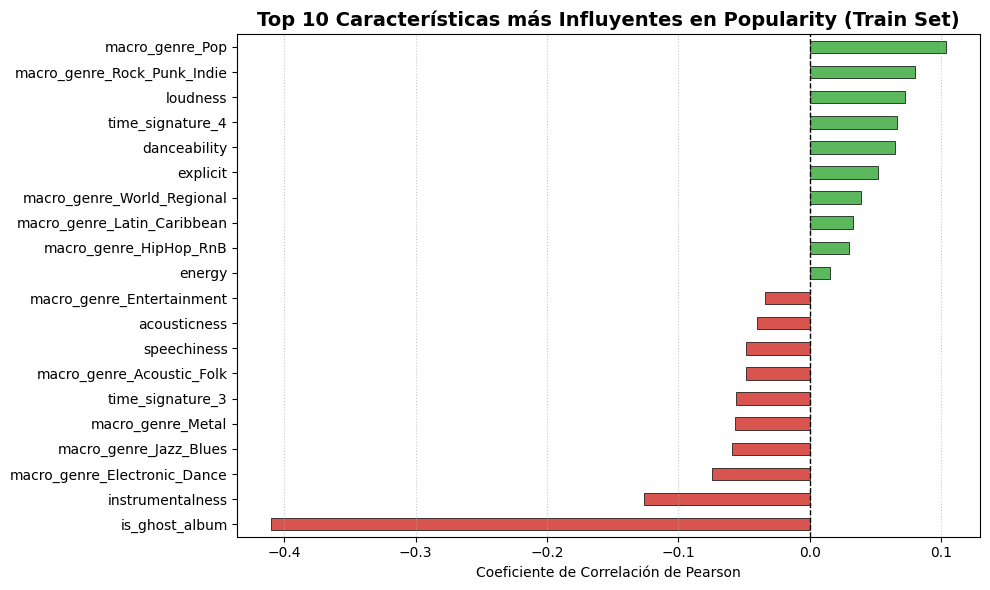

In [35]:
# 1. Unir temporalmente las características procesadas con el target
df_train_corr = X_train_processed.copy()
df_train_corr['popularity'] = y_train.values

# 2. Calcular la correlación de Pearson y aislar 'popularity'
corr_popularity_nueva = (
    df_train_corr.corr(method='pearson')['popularity']
    .drop('popularity')
    .sort_values(ascending=True)
)

# 3. Filtrar el Top 5 más negativo y el Top 5 más positivo
top_10_corr = pd.concat([corr_popularity_nueva.head(10), corr_popularity_nueva.tail(10)])

# 4. Visualización enfocada en el Top 10
plt.figure(figsize=(10, 6)) # Se redujo la altura al ser solo 10 barras
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in top_10_corr.values]

top_10_corr.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)

plt.title('Top 10 Características más Influyentes en Popularity (Train Set)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Hallazgos Claves 

    El impacto masivo del Álbum Fantasma (is_ghost_album): Posee una correlación negativa extrema cercana a -0.41. Esto valida la ingeniería de variables: los discos que no registraron actividad previa arrastran masivamente a la baja la popularidad de sus pistas, actuando como un potente filtro temporal. 
    
    Factores comerciales positivos: Los macro-géneros comerciales como macro_genre_Pop y macro_genre_Rock_Punk_Indie lideran las correlaciones positivas. 
    
    Atributos físicos como loudness (volumen de masterización), danceability (bailabilidad) y el compás estándar time_signature_4 (ritmo comercial de 4/4) impulsan positivamente el éxito de la canción. 
    
    El contenido explicit también muestra una ligera tendencia positiva, ligada al consumo de música urbana y comercial actual. 
    
    Factores de penalización comercial: La instrumentalness presenta una correlación negativa fuerte (-0.12). Las pistas sin voces o vocales predominantes tienden a escasear en las listas de alta popularidad de streaming. 
    
    Elementos acústicos puros como acousticness o altas tasas de speechiness (hablar/rap extremadamente hablado) penalizan linealmente la popularidad en este dataset. 
    
    Ciertos nichos como macro_genre_Electronic_Dance, macro_genre_Jazz_Blues y macro_genre_Metal muestran valores negativos frente al promedio general de popularidad de la plataforma.




### *3.5 Validación y Conclusiones del Pipeline de Datos*




1. Eliminamos la columna residual del índice y la única fila con valores nulos para despejar la matriz desde el inicio. Luego, abordamos el problema crítico de los duplicados y conservamos solo una aparición de cada identificador único de canción. Esto evita que el modelo haga trampa al memorizar una pista repetida artificialmente en varios géneros, lo que habría contaminado nuestro conjuntos de entrenamiento y prueba. Finalmente, purgamos los atípicos operativos eliminando pistas con duración igual a cero y aquellas que excedían los 15 minutos, sacando de la ecuación audiolibros, sonidos de lluvia y errores de la API que confundirían al algoritmo al no ser música tradicional.

2. La segunda fase se enfocó en la ingeniería de características estática. Agrupamos los 114 géneros originales en 12 macro-géneros semánticos. Esto reduce drásticamente la dimensionalidad para que el modelo no se disperse y le otorga una explicabilidad de negocio directa a tus predicciones. Además, convertimos la etiqueta booleana de contenido explícito a ceros y unos, y transformamos las variables de tonalidad y compás a formato de texto. Al forzarlas como texto, bloqueamos la posibilidad de que el modelo asuma falsamente que un tono 11 tiene un valor o peso matemático mayor que un tono 0.

3. Luego aplicamos la división de datos (Train-Test Split). Separamos la matriz en características predictoras y cortamos todo en un conjunto de entrenamiento y uno de prueba. Con la finalidad de que las transformaciones estadísticas dinámicas no se contaminen jamás con información del futuro.

4. Dentro del entorno seguro de entrenamiento, activamos la ingeniería dinámica con el transformador de álbumes. Diseñamos una regla lógica que agrupa las canciones por álbum y busca su popularidad máxima; si el máximo es cero, marca todas las pistas de ese disco como un álbum "fantasma" o sin popularidad. Al construirlo como un objeto de transformación personalizado, garantizamos que la regla se aprenda exclusivamente con el historial de entrenamiento. Si en los datos de prueba ingresa un álbum que el modelo nunca ha visto, el sistema lo identifica como nulo y automáticamente le aplica el mismo castigo de falta de popularidad, protegiendo nuestra evaluación de errores.

5. La última capa fue el ensamble de escalado y codificación. Separamos el trato de las columnas según su naturaleza matemática: enviamos las métricas con colas largas (duración, volumen y tempo) a un escalador robusto que comprime el rango ignorando los atípicos severos (RobustScaler); pasamos las métricas que nacen acotadas entre 0 y 1 (como la bailabilidad o la energía) por un escalador Min-Max para asegurar que los modelos basados en distancias funcionen con simetría perfecta; y convertimos los macro-géneros, la tonalidad y el compás en columnas binarias individuales independientes.

6. En cuanto a la variable objetivo (popularity), la extrajimos y aislamos del pipeline de transformación por completo desde el paso previo a la división, ya que los predictores no deben cruzarse nunca con lo que intentan adivinar. 

### *3.6 Implementaciónes Futuras (Susceptible de cambio)*


Dado que descubrimos que un 14% de las canciones son un bloque de ceros y que el algoritmo de Spotify asigna puntajes de forma exponencial basándose en la frescura de las reproducciones, decidimos que la variable objetivo no puede atacarse de frente con un regresor tradicional. Por lo tanto la idea es dividir la predicción en un modelo de dos etapas: primero se convierte internamente en una clase binaria para entrenar un modelo que adivine si la canción sera popular o no. Luego, tomando únicamente las canciones que sobrevivieron a ese filtro positivo, se le aplicara una transformación matemática logarítmica para aplanar su curva exponencial y se entrena un regresor que prediga la magnitud real de su éxito.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d9e4801b-3255-44b3-8020-c64ca67fe951' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>